In [1]:
!pip install -q groq sentence-transformers scikit-learn tqdm

import os, json, time, re, hashlib, random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from groq import Groq
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.4 MB/s eta 0:00:00


# Configuración

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, shutil, json
import pandas as pd
from sklearn.metrics import roc_auc_score
os.chdir('/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/notebooks')
OUTDIR = "/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/simMIA"
os.makedirs(OUTDIR, exist_ok=True)

BACKEND = "groq"
MODEL = "llama-3.3-70b-versatile"
METHOD = "simmia"
LENGTH = "medium"

N_SAMPLES = 3       # muestras por prefijo
MAX_WORDS = 20      # palabras del texto usadas
MAX_NEW_TOKENS = 3  # queremos que genere próxima palabra / mini continuación
SLEEP_BETWEEN_CALLS = 2.1
SEED = 2319

BASE_DIR = "/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026"
DATASET_PATH = "/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/datasets/evaluation/booktection_medium_eval_20books_10chunks.csv"

API_LOG_DIR = os.path.join(BASE_DIR, "api_logs", METHOD, MODEL.replace("/", "_"))
RESULTS_DIR = os.path.join(BASE_DIR, "results", METHOD, MODEL.replace("/", "_"))

os.makedirs(API_LOG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

try:
    from google.colab import userdata

    api_keys = []

    for i in range(1, 9):
        name = "GROQ_API_KEY" if i == 1 else f"GROQ_API_KEY{i}"
        try:
            k = userdata.get(name)
            if k:
                api_keys.append(k)
        except:
            pass

except Exception:
    api_keys = []

print(f"Se cargaron {len(api_keys)} API Keys")

current_key = 0
client = Groq(api_key=api_keys[current_key])

HF_TOKEN = userdata.get("HGF")

Mounted at /content/drive
Se cargaron 8 API Keys


# Cargar dataset

In [3]:
df = pd.read_csv(DATASET_PATH)
df = df[df["length"] == LENGTH].reset_index(drop=True)

print(df.shape)
display(df.head(2))

(200, 10)


,sample_id,book_id,label,length,answer,text,Example_A,Example_B,Example_C,Example_D
0,BT_0000,1984_-_George_Orwell,1,medium,A,Since he was arrested he had not been fed. He ...,Since he was arrested he had not been fed. He ...,He had not eaten anything since being arrested...,"Since his arrest, he had been given nothing to...",He had been given no food since being arrested...
1,BT_0001,The_Alchemist_-_Paulo_Coelho,1,medium,A,"“And I know the Soul of the World, because we ...","“And I know the Soul of the World, because we ...",The essence of the universe has confided in me...,I'm privy to the psyche of the cosmos from our...,The spirit of the world has confided in me dur...


# Backend del modelo


In [4]:
embedder = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    token=HF_TOKEN
)

def similarity(w1, w2):
    if not isinstance(w1, str) or not isinstance(w2, str):
        return 0.0
    if not w1.strip() or not w2.strip():
        return 0.0

    e1 = embedder.encode([w1])
    e2 = embedder.encode([w2])
    cos = cosine_similarity(e1, e2)[0][0]
    return float((cos + 1) / 2)

def first_word(text):
    if text is None:
        return ""
    text = str(text).strip()
    text = re.sub(r"^[^\w]+", "", text)
    parts = text.split()
    return parts[0] if parts else ""

def switch_api_key():
    global current_key, client

    if current_key + 1 >= len(api_keys):
        raise DailyCapError("Todas las API keys agotadas.")

    current_key += 1
    client = Groq(api_key=api_keys[current_key])

    print(f"\n🔑 Cambiando a API KEY #{current_key+1}")

class DailyCapError(Exception):
    pass

def safe_generate(prefix, max_retries=6):
    for attempt in range(max_retries):
        try:
            r = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {
                        "role": "system",
                        "content": "Continue the text naturally. Output only the next word or very short continuation."
                    },
                    {
                        "role": "user",
                        "content": prefix
                    }
                ],
                max_tokens=MAX_NEW_TOKENS,
                temperature=1.0,
                top_p=1.0,
                seed=SEED + attempt
            )
            return r.choices[0].message.content.strip()

        except Exception as e:
            msg = str(e)

            if "429" not in msg and "rate_limit" not in msg.lower():
                raise

            if "per day" in msg.lower() or "TPD" in msg or "RPD" in msg:
                switch_api_key()
                continue

            m2 = re.search(r"try again in (\d+)m([\d.]+)s", msg)
            m1 = re.search(r"try again in ([\d.]+)s", msg)

            wait = (
                int(m2.group(1)) * 60 + float(m2.group(2))
                if m2 else
                float(m1.group(1)) if m1 else 20.0
            )

            time.sleep(wait + 1)

    raise RuntimeError("max_retries agotado")

def save_json(path, data):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def make_query_id(sample_id, position, sample_idx):
    raw = f"{METHOD}|{MODEL}|{sample_id}|{position}|{sample_idx}|{MAX_WORDS}|{N_SAMPLES}|{SEED}"
    return hashlib.md5(raw.encode("utf-8")).hexdigest()


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# simMIA

In [5]:
query_records = []
token_records = []
sample_records = []

stopped = False

for _, row in tqdm(df.iterrows(), total=len(df), desc="SimMIA samples"):

    sample_id = row["sample_id"]
    book_id = row["book_id"]
    label = int(row["label"])
    text = row["text"]

    words = str(text).split()[:MAX_WORDS]

    if len(words) < 2:
        continue

    token_scores = []

    try:
        for i in range(1, len(words)):
            prefix = " ".join(words[:i])
            target_word = words[i]

            generated_words = []
            similarities = []

            for sample_idx in range(N_SAMPLES):
                query_id = make_query_id(sample_id, i, sample_idx)
                log_path = os.path.join(API_LOG_DIR, f"{query_id}.json")

                if os.path.exists(log_path):
                    record = load_json(log_path)
                    generated = record["generated_text"]
                    gen_word = record["generated_first_word"]
                    sim = record["similarity"]

                else:
                    generated = safe_generate(prefix)
                    gen_word = first_word(generated)
                    sim = similarity(target_word, gen_word)

                    record = {
                        "query_id": query_id,
                        "method": METHOD,
                        "model": MODEL,
                        "backend": BACKEND,
                        "sample_id": sample_id,
                        "book_id": book_id,
                        "label": label,
                        "length": LENGTH,
                        "position": i,
                        "prefix": prefix,
                        "target_word": target_word,
                        "sample_idx": sample_idx,
                        "generated_text": generated,
                        "generated_first_word": gen_word,
                        "similarity": sim,
                        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
                    }

                    save_json(log_path, record)

                    if SLEEP_BETWEEN_CALLS:
                        time.sleep(SLEEP_BETWEEN_CALLS)

                query_records.append(record)
                generated_words.append(gen_word)
                similarities.append(sim)

            word_score = float(np.mean(similarities))
            token_scores.append(word_score)

            token_records.append({
                "sample_id": sample_id,
                "book_id": book_id,
                "label": label,
                "position": i,
                "prefix": prefix,
                "target_word": target_word,
                "word_score": word_score,
                "n_samples": N_SAMPLES,
                "generated_words": generated_words
            })

        membership_score = float(np.mean(token_scores))

        sample_records.append({
            "sample_id": sample_id,
            "book_id": book_id,
            "label": label,
            "method": METHOD,
            "model": MODEL,
            "backend": BACKEND,
            "membership_score": membership_score,
            "n_positions": len(token_scores),
            "max_words": MAX_WORDS,
            "n_samples_per_prefix": N_SAMPLES,
            "absolute_error": abs(label - membership_score)
        })

    except DailyCapError:
        stopped = True
        print("\n⚠️ Cap diario de Groq alcanzado.")
        print("Reanudá después re-corriendo esta celda: las consultas ya guardadas no se repiten.")
        break

SimMIA samples:   0%|          | 0/200 [00:00<?, ?it/s]


🔑 Cambiando a API KEY #2

🔑 Cambiando a API KEY #3

🔑 Cambiando a API KEY #4

🔑 Cambiando a API KEY #5

🔑 Cambiando a API KEY #6

🔑 Cambiando a API KEY #7

🔑 Cambiando a API KEY #8

⚠️ Cap diario de Groq alcanzado.
Reanudá después re-corriendo esta celda: las consultas ya guardadas no se repiten.


# Resultados

In [6]:
query_df = pd.DataFrame(query_records)
token_df = pd.DataFrame(token_records)
sample_df = pd.DataFrame(sample_records)

query_csv = os.path.join(RESULTS_DIR, "simmia_query_level_results.csv")
token_csv = os.path.join(RESULTS_DIR, "simmia_token_level_results.csv")
sample_csv = os.path.join(RESULTS_DIR, "simmia_sample_level_results.csv")

query_df.to_csv(query_csv, index=False)
token_df.to_csv(token_csv, index=False)
sample_df.to_csv(sample_csv, index=False)

print("CORTADO por cap diario." if stopped else "COMPLETO.")
print("Queries guardadas:", len(query_df))
print("Tokens completos:", len(token_df))
print("Samples completos:", len(sample_df))

print("\nQuery-level:", query_csv)
print("Token-level:", token_csv)
print("Sample-level:", sample_csv)

display(sample_df.head())

CORTADO por cap diario.
Queries guardadas: 11385
Tokens completos: 3795
Samples completos: 199

Query-level: /content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/results/simmia/llama-3.3-70b-versatile/simmia_query_level_results.csv
Token-level: /content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/results/simmia/llama-3.3-70b-versatile/simmia_token_level_results.csv
Sample-level: /content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/results/simmia/llama-3.3-70b-versatile/simmia_sample_level_results.csv


,sample_id,book_id,label,method,model,backend,membership_score,n_positions,max_words,n_samples_per_prefix,absolute_error
0,BT_0000,1984_-_George_Orwell,1,simmia,llama-3.3-70b-versatile,groq,0.799582,19,20,3,0.200418
1,BT_0001,The_Alchemist_-_Paulo_Coelho,1,simmia,llama-3.3-70b-versatile,groq,0.790942,19,20,3,0.209058
2,BT_0002,Oliver_Twist_-_Charles_Dickens,1,simmia,llama-3.3-70b-versatile,groq,0.715594,19,20,3,0.284406
3,BT_0003,Unfortunately_Yours_-_Tessa_Bailey,0,simmia,llama-3.3-70b-versatile,groq,0.748153,19,20,3,0.748153
4,BT_0004,The_Foxglove_King_-_Hannah_Whitten,0,simmia,llama-3.3-70b-versatile,groq,0.725169,19,20,3,0.725169


Modelo: llama-3.3-70b-versatile
Método: SimMIA
Samples completos: 199

Mean Absolute Error:
0.49353987500853164

Error por clase:
label
0    0.752176
1    0.237491
Name: absolute_error, dtype: float64

AUC: 0.5732323232323232
AUC invertido: 0.42676767676767674


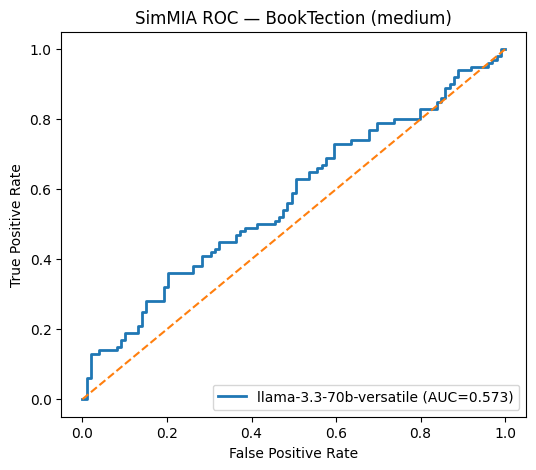


Métricas guardadas en:
/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/results/simmia/llama-3.3-70b-versatile/simmia_metrics_summary.csv


In [7]:
if len(sample_df) > 0:
    print("Modelo:", MODEL)
    print("Método: SimMIA")
    print("Samples completos:", len(sample_df))

    print("\nMean Absolute Error:")
    print(sample_df["absolute_error"].mean())

    print("\nError por clase:")
    print(sample_df.groupby("label")["absolute_error"].mean())

    if sample_df["label"].nunique() == 2:
        y = sample_df["label"].values
        s = sample_df["membership_score"].values

        auc = roc_auc_score(y, s)
        auc_inv = roc_auc_score(y, -s)

        print("\nAUC:", auc)
        print("AUC invertido:", auc_inv)

        fpr, tpr, _ = roc_curve(y, s)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, lw=2, label=f"{MODEL} (AUC={auc:.3f})")
        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"SimMIA ROC — BookTection ({LENGTH})")
        plt.legend(loc="lower right")
        plt.show()

        metrics_path = os.path.join(RESULTS_DIR, "simmia_metrics_summary.csv")

        metrics_summary = pd.DataFrame([{
            "method": METHOD,
            "model": MODEL,
            "backend": BACKEND,
            "length": LENGTH,
            "n_samples": len(sample_df),
            "max_words": MAX_WORDS,
            "n_samples_per_prefix": N_SAMPLES,
            "mean_absolute_error": sample_df["absolute_error"].mean(),
            "mean_error_members": sample_df[sample_df["label"] == 1]["absolute_error"].mean(),
            "mean_error_non_members": sample_df[sample_df["label"] == 0]["absolute_error"].mean(),
            "auc": auc,
            "auc_inverted": auc_inv
        }])

        metrics_summary.to_csv(metrics_path, index=False)

        print("\nMétricas guardadas en:")
        print(metrics_path)
    else:
        print("\nTodavía no se puede calcular AUC: falta una de las clases.")